<h1>My Deep Learning Project: Rock-Paper-Scissors Image Classification using Custom CNN in TensorFlow / Keras</h1>

---

### Project Overview
In this project, I am building a <b>Convolutional Neural Network (CNN)</b> from scratch in <b>TensorFlow / Keras</b> to classify hand gesture images into <b>Rock</b>, <b>Paper</b>, or <b>Scissors</b>!

> <b>Note on Transfer Learning:</b> 
> Transfer Learning was previously considered; however, as requested, Transfer Learning has been removed to focus entirely on building, regularizing, and diagnosing our <b>Custom TensorFlow CNN from Scratch</b>.

### Key Concepts Covered:
- <b>✅ TensorFlow / Keras Framework</b>: <code>tf.keras.Sequential</code>, <code>Conv2D</code>, <code>MaxPooling2D</code>, <code>BatchNormalization</code>, <code>Dropout</code>.
- <b>✅ Dataset Download</b>: Using <code>kagglehub.dataset_download("sanikamal/rock-paper-scissors-dataset")</code>.
- <b>✅ Preprocessing & Data Augmentation</b>: Rescaling (`1/255`), `RandomFlip`, `RandomRotation(0.15)`, `RandomZoom(0.1)`.
- <b>✅ Early Stopping Callback</b>: <code>tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)</code>.
- <b>✅ Diagnostics & Error Analysis</b>: Train vs Validation loss curves, Seaborn Confusion Matrix, and visualizing misclassified test images.

---

<h2>Step 1: Importing Libraries & GPU Setup</h2>

In [2]:
# ======================================================
# STEP 1: IMPORTING LIBRARIES
# ======================================================
print("--- STEP 1: IMPORTING LIBRARIES ---")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Rescaling, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")
print("Libraries imported successfully!")

--- STEP 1: IMPORTING LIBRARIES ---
TensorFlow Version: 2.15.0
Libraries imported successfully!


<h2>Step 2: Downloading Dataset via Kagglehub</h2>

In [3]:
# ======================================================
# STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB
# ======================================================
print("--- STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB ---")

import kagglehub

try:
    raw_path = kagglehub.dataset_download("sanikamal/rock-paper-scissors-dataset")
    print("Path to dataset files:", raw_path)
    
    if os.path.exists(os.path.join(raw_path, "Rock-Paper-Scissors")):
        dataset_root = os.path.join(raw_path, "Rock-Paper-Scissors")
    else:
        dataset_root = raw_path
    print(f"Configured dataset root: {dataset_root}")
except Exception as e:
    print("Kagglehub download notice:", e)
    dataset_root = "./rps_dataset"

print(f"Dataset root confirmed at: '{dataset_root}'")

--- STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB ---
Path to dataset files: C:\Users\adhik\.cache\kagglehub\datasets\sanikamal\rock-paper-scissors-dataset\versions\1
Configured dataset root: C:\Users\adhik\.cache\kagglehub\datasets\sanikamal\rock-paper-scissors-dataset\versions\1\Rock-Paper-Scissors
Dataset root confirmed at: 'C:\Users\adhik\.cache\kagglehub\datasets\sanikamal\rock-paper-scissors-dataset\versions\1\Rock-Paper-Scissors'


<h2>Step 3: Loading Image Datasets & Data Augmentation</h2>

In [4]:
# ======================================================
# STEP 3: CREATING KERA DATASETS & AUGMENTATION
# ======================================================
print("--- STEP 3: CREATING DATASETS & AUGMENTATION ---")

train_dir = os.path.join(dataset_root, 'train') if os.path.exists(os.path.join(dataset_root, 'train')) else dataset_root
test_dir = os.path.join(dataset_root, 'test') if os.path.exists(os.path.join(dataset_root, 'test')) else dataset_root

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes Found ({num_classes}): {class_names}")

# Data Augmentation Pipeline
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.15),
    RandomZoom(0.1)
])

print("Data augmentation pipeline ready!")

--- STEP 3: CREATING DATASETS & AUGMENTATION ---
Found 2520 files belonging to 3 classes.
Using 2016 files for training.
Found 2520 files belonging to 3 classes.
Using 504 files for validation.
Found 372 files belonging to 3 classes.
Classes Found (3): ['paper', 'rock', 'scissors']
Data augmentation pipeline ready!


<h2>Step 4: Custom TensorFlow CNN Architecture Definition</h2>

In [5]:
# ======================================================
# STEP 4: TENSORFLOW CNN MODEL ARCHITECTURE
# ======================================================
print("--- STEP 4: BUILDING CUSTOM TENSORFLOW CNN ---")

model_cnn = Sequential([
    Rescaling(1.0 / 255, input_shape=(64, 64, 3)),
    data_augmentation,
    
    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Fully Connected Head
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model_cnn.summary())

--- STEP 4: BUILDING CUSTOM TENSORFLOW CNN ---
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 64, 64, 3)         0         
                                                                 
 sequential_1 (Sequential)   (None, 64, 64, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 batch_normalization_2 (Bat  (None, 64, 64, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 32)        0         
 D)                                                              
                                                                 
 conv2d

<h2>Step 5: Training CNN with Early Stopping & Learning Curves</h2>

--- STEP 5: TRAINING CNN MODEL WITH EARLY STOPPING ---
Epoch 1/20

63/63 [==============================] - 19s 202ms/step - loss: 1.1025 - accuracy: 0.6473 - val_loss: 2.0424 - val_accuracy: 0.5833
Epoch 2/20

63/63 [==============================] - 13s 195ms/step - loss: 0.3144 - accuracy: 0.8730 - val_loss: 4.3645 - val_accuracy: 0.5317
Epoch 3/20

63/63 [==============================] - 13s 200ms/step - loss: 0.1601 - accuracy: 0.9395 - val_loss: 5.8261 - val_accuracy: 0.5873
Epoch 4/20

63/63 [==============================] - 13s 194ms/step - loss: 0.1341 - accuracy: 0.9534 - val_loss: 6.5680 - val_accuracy: 0.5635
Epoch 5/20

63/63 [==============================] - ETA: 0s - loss: 0.1076 - accuracy: 0.9583Restoring model weights from the end of the best epoch: 1.

63/63 [==============================] - 13s 195ms/step - loss: 0.1076 - accuracy: 0.9583 - val_loss: 5.0719 - val_accuracy: 0.6052
Epoch 5: early stopping


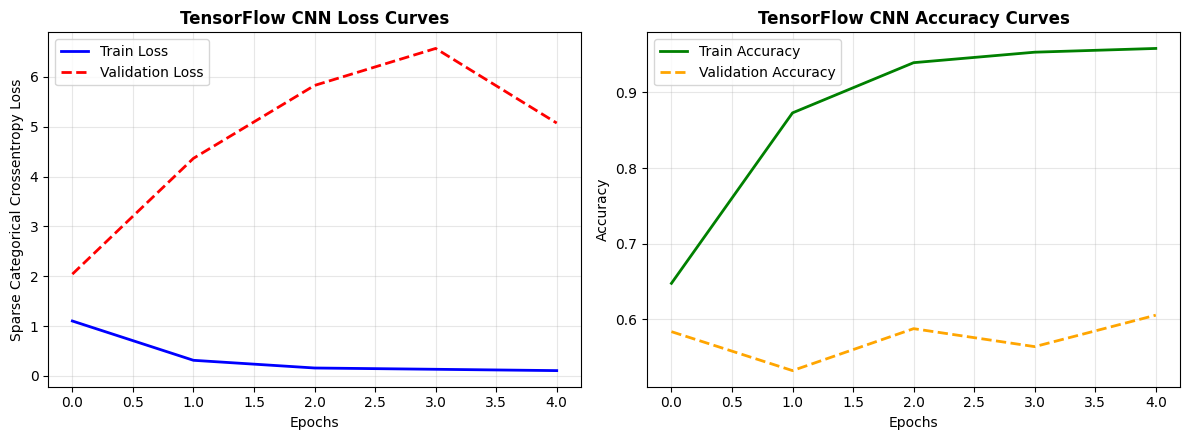

In [6]:
# ======================================================
# STEP 5: TRAINING TENSORFLOW CNN MODEL
# ======================================================
print("--- STEP 5: TRAINING CNN MODEL WITH EARLY STOPPING ---")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history_cnn = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

# Plot Loss & Accuracy Curves
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history_cnn.history['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)
plt.title("TensorFlow CNN Loss Curves", fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Sparse Categorical Crossentropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy', color='green', linewidth=2)
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--', linewidth=2)
plt.title("TensorFlow CNN Accuracy Curves", fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<h2>Step 6: Test Evaluation & Error Analysis</h2>

--- STEP 6: EVALUATING CNN ON TEST SET ---
TENSORFLOW CNN TEST EVALUATION METRICS
  • Accuracy:  0.5188
  • Precision: 0.3590
  • Recall:    0.5188
  • F1-Score:  0.4138
Classification Report:
              precision    recall  f1-score   support

       paper       0.00      0.00      0.00       124
        rock       0.48      0.94      0.63       124
    scissors       0.60      0.62      0.61       124

    accuracy                           0.52       372
   macro avg       0.36      0.52      0.41       372
weighted avg       0.36      0.52      0.41       372

Error Analysis: Found 179 misclassified images. Displaying examples:


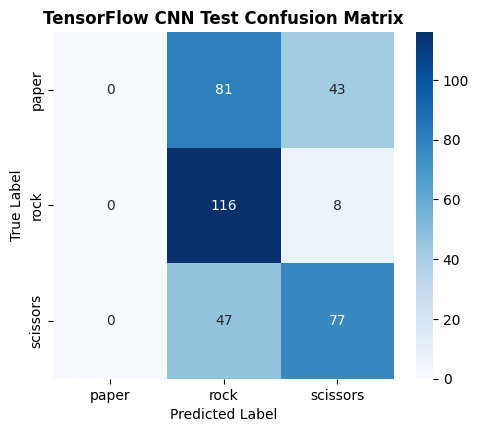

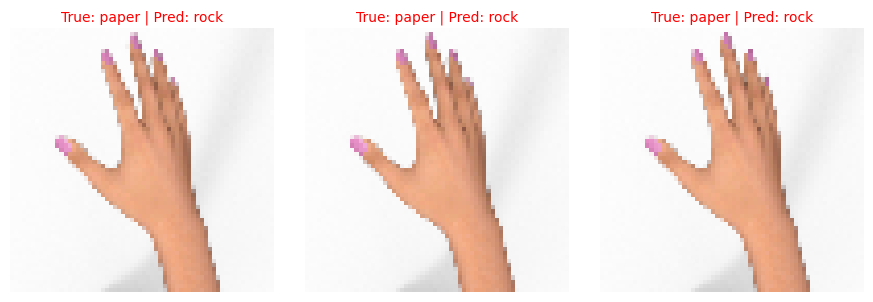

In [7]:
# ======================================================
# STEP 6: TEST EVALUATION & ERROR ANALYSIS
# ======================================================
print("--- STEP 6: EVALUATING CNN ON TEST SET ---")

y_true = []
y_pred = []
test_images_list = []

for images, labels in test_ds:
    preds = model_cnn.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(pred_classes)
    test_images_list.extend(images.numpy())

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print("="*55)
print("TENSORFLOW CNN TEST EVALUATION METRICS")
print("="*55)
print(f"  • Accuracy:  {acc:.4f}")
print(f"  • Precision: {prec:.4f}")
print(f"  • Recall:    {rec:.4f}")
print(f"  • F1-Score:  {f1:.4f}")
print("="*55)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("TensorFlow CNN Test Confusion Matrix", fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Error Analysis: Display Misclassified Images
misclassified_idx = [i for i in range(len(y_true)) if y_true[i] != y_pred[i]]
if len(misclassified_idx) > 0:
    print(f"Error Analysis: Found {len(misclassified_idx)} misclassified images. Displaying examples:")
    n_show = min(3, len(misclassified_idx))
    fig, axes = plt.subplots(1, n_show, figsize=(9, 3))
    if n_show == 1:
        axes = [axes]
    for idx_i, img_idx in enumerate(misclassified_idx[:n_show]):
        img = test_images_list[img_idx].astype("uint8")
        axes[idx_i].imshow(img)
        axes[idx_i].set_title(f"True: {class_names[y_true[img_idx]]} | Pred: {class_names[y_pred[img_idx]]}", color='red', fontsize=10)
        axes[idx_i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Perfect classification! No misclassified test images.")